# Exploratory Data Analysis (EDA)

## Structure and missing values

Checking shapes, column types and missing values

In [1]:
import pandas as pd
from features import *

data = pd.read_csv("train.csv")
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [2]:
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
data.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [4]:
data.shape

(1460, 81)

In [5]:
data.isna().sum() / len(data) * 100

Id                0.000000
MSSubClass        0.000000
MSZoning          0.000000
LotFrontage      17.739726
LotArea           0.000000
                   ...    
MoSold            0.000000
YrSold            0.000000
SaleType          0.000000
SaleCondition     0.000000
SalePrice         0.000000
Length: 81, dtype: float64

## Missing Values:

 - `PoolQC` NA converted to False (no pool), any quality values (Ex, Gd, TA, Fa) converted to True (HasPool)
 - `MiscFeature` Rejected - all its information is captured more completely by `MiscVal`. (0 = no additional feature, i.e. the numeric equivalent of `MiscFeature`'s NaN)
 - `Alley` NA converted to 'NoAlley', then one-hot encoded
 - `Fence` NA converted to 'NoFence', then one-hot encoded
 - `MasVnrType` NA converted to 'NoMasonryVeneer', then one-hot encoded
 - `FireplaceQu` Manually mapped to ordinal values (0=None, 1=Po, 2=Fa, 3=TA, 4=Gd, 5=Ex)
 - `LotFrontage` Due to significant disparity in results across neighborhoods (from 21 to 91) - NaN values were replaced with the median `LotFrontage` of the respective neighborhood, not global median
 - `GarageQual` Manually mapped to ordinal values (0=None, 1=Po, 2=Fa, 3=TA, 4=Gd, 5=Ex)
 - `GarageType` NA converted to 'NoGarage', then one-hot encoded
 - `GarageFinish` NA converted to 'NoGarage', then one-hot encoded
 - `GarageCond` Manually mapped to ordinal values (0=None, 1=Po, 2=Fa, 3=TA, 4=Gd, 5=Ex)
 - `BsmtQual` Manually mapped to ordinal values (0=None, 1=Po, 2=Fa, 3=TA, 4=Gd, 5=Ex)
 - `BsmtCond` Manually mapped to ordinal values (0=None, 1=Po, 2=Fa, 3=TA, 4=Gd, 5=Ex)
 - `BsmtExposure` Manually mapped to ordinal values (0=None, 1=No, 2=Mn, 3=Av, 4=Gd)
 - `BsmtFinType1` Manually mapped to ordinal values (0=None, 1=Unf, 2=LwQ, 3=Rec, 4=BLQ, 5=ALQ, 6=GLQ)
 - `BsmtFinType2` Manually mapped to ordinal values (0=None, 1=Unf, 2=LwQ, 3=Rec, 4=BLQ, 5=ALQ, 6=GLQ)
 - `GarageYrBlt` NaN replaced with `YearBuilt`
 - `MasVnrArea` NA converted to 0
 - `Electrical` Just one missing value replaced by most common value

In [6]:
pool_qc(data)
misc_feature(data)
alley(data)
fence(data)
mas_vnr_type(data)
fireplace_qu(data)
lot_frontage(data)
garage_qual(data)
garage_type(data)
garage_finish(data)
garage_cond(data)
bsmt_cond(data)
bsmt_qual(data)
bsmt_exposure(data)
bsmt_fin_type1(data)
bsmt_fin_type2(data)
garage_yr_blt(data)
mas_vnr_area(data)
electrical(data)
data.isna().sum() / len(data) * 100

Id               0.0
MSSubClass       0.0
MSZoning         0.0
LotFrontage      0.0
LotArea          0.0
                ... 
MoSold           0.0
YrSold           0.0
SaleType         0.0
SaleCondition    0.0
SalePrice        0.0
Length: 81, dtype: float64

## Histograms

<Axes: >

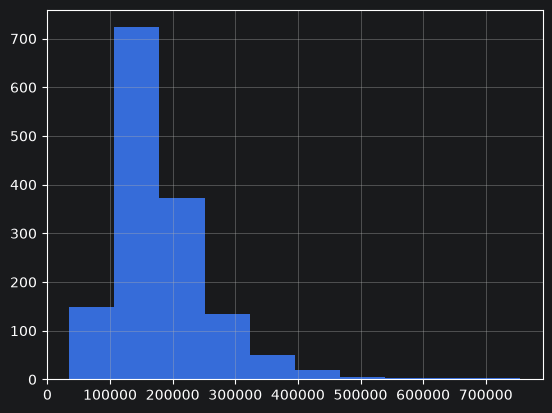

In [10]:
data['SalePrice'].hist()

<Axes: >

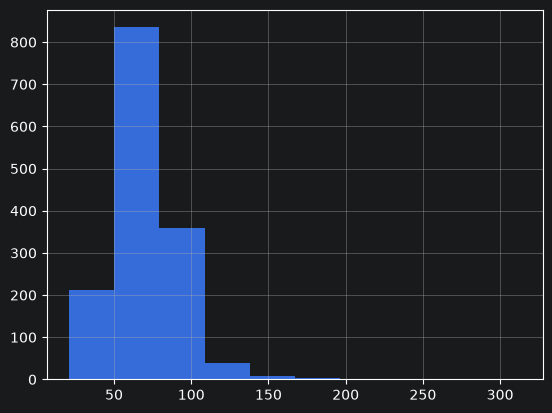

In [7]:
data['LotFrontage'].hist()

In [8]:
data.groupby('Neighborhood')['LotFrontage'].median()

Neighborhood
Blmngtn    43.0
Blueste    24.0
BrDale     21.0
BrkSide    52.0
ClearCr    80.0
CollgCr    70.0
Crawfor    74.0
Edwards    65.5
Gilbert    65.0
IDOTRR     60.0
MeadowV    21.0
Mitchel    73.0
NAmes      73.0
NPkVill    24.0
NWAmes     80.0
NoRidge    91.0
NridgHt    88.5
OldTown    60.0
SWISU      60.0
Sawyer     71.0
SawyerW    66.5
Somerst    73.5
StoneBr    61.5
Timber     85.0
Veenker    68.0
Name: LotFrontage, dtype: float64

In [9]:
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NoAlley,Reg,Lvl,AllPub,...,0,False,NoFence,False,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NoAlley,Reg,Lvl,AllPub,...,0,False,NoFence,False,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NoAlley,IR1,Lvl,AllPub,...,0,False,NoFence,False,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NoAlley,IR1,Lvl,AllPub,...,0,False,NoFence,False,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NoAlley,IR1,Lvl,AllPub,...,0,False,NoFence,False,0,12,2008,WD,Normal,250000


## Correlation Matrix with target value

In [11]:
data.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
FireplaceQu      0.520438
GarageYrBlt      0.508043
YearRemodAdd     0.507101
MasVnrArea       0.472614
Fireplaces       0.466929
BsmtFinSF1       0.386420
BsmtExposure     0.374696
LotFrontage      0.349876
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
BsmtFinType1     0.304908
HalfBath         0.284108
GarageQual       0.273839
LotArea          0.263843
GarageCond       0.263191
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolQC           0.093708
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinType2    -0.005323
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id          

<Axes: title={'center': 'SalePrice'}, xlabel='OverallQual'>

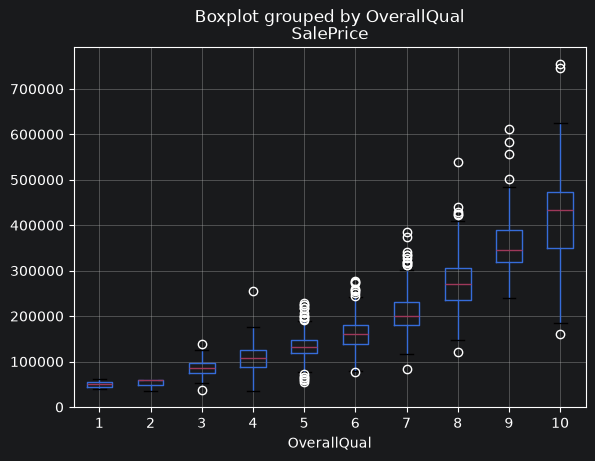

In [12]:
data.boxplot(column='SalePrice', by='OverallQual')

## Hypothesis

 - `SalePrice` Right skewness - logarithm transformation for target feature